# Age at First Infection

## Theory

In an endemic SIR system with vital dynamics, the **age at first infection**
$A$ follows (approximately) an exponential distribution with mean:

$$A = \frac{1}{\lambda^*}$$

where $\lambda^* = \beta I^*/N$ is the **force of infection** at the
endemic equilibrium.  The endemic infectious fraction is:

$$\frac{I^*}{N} = \frac{\mu(R_0 - 1)}{\beta}$$

so $\lambda^* = \mu(R_0 - 1)$, and $A = 1/(\mu(R_0 - 1))$.  For
measles-like parameters (R₀ = 5, μ = 20/1000/yr), this gives A ≈ 2.5 years.

**Cohort-model limitation:** laser.cohorts tracks *compartment counts*, not
individuals.  We therefore cannot record the exact age at which each person
becomes infected.  Instead, we:
1. Run the model and extract the `newly_infectious` node property (new
   infections per tick), which is the tick-level incidence.
2. Use incidence as a proxy for the force of infection λ(t) ≈ new_inf(t)/S(t).
3. Compare the time-averaged λ to the theoretical λ* and derive A.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from laser.core import PropertySet
from laser.core.utils import grid
from laser.generic.utils import ValuesMap
from laser.cohorts import Model, Campaign, Intervention
from laser.cohorts.vitaldynamics import NonDiseaseMortality, ConstantPopBirths
import laser.cohorts.SIR as SIR


class Importation(Intervention):
    """Add a fixed count of infectious individuals to targeted nodes each scheduled tick."""

    @property
    def states(self):
        return []

    @property
    def properties(self):
        return []

    def execute(self, tick, who, where, params, notes):
        count  = int(params.get("count", 1))
        target = where if where is not None else list(range(len(self.model.scenario)))
        I_idx  = self.model.states.get_state_index("I")
        if I_idx is None:
            return
        for node in target:
            self.model.states[tick + 1][I_idx, node] += count


Campaign.register(Importation)

In [2]:
# Parameters
N              = 500_000
I0             = 50
CDR            = 20             # crude death rate per 1000 per year
r_mortality_val = CDR / 1000 / 365
beta           = 0.5
gamma          = 0.1
nticks         = 50 * 365       # 50 years

# Annual importation to prevent stochastic extinction
import_period = 365
when_ticks   = list(range(0, nticks, import_period))

scenario = grid(M=1, N=1)
scenario["S"] = N - I0
scenario["I"] = I0
scenario["R"] = 0

params = PropertySet({"nticks": nticks})
model  = Model(scenario, params)

schedule = [{"who": "*", "what": "Importation", "when": when_ticks,
             "where": [0], "parameters": {"count": 1}, "notes": ""}]
campaign = Campaign(model, schedule)

betas        = ValuesMap.from_scalar(beta,  nticks, 1)
r_recoveries = ValuesMap.from_scalar(gamma, nticks, 1)

model.components = [
    SIR.Susceptible(model),
    SIR.Infectious(model, r_recovery=r_recoveries),
    SIR.Recovered(model),
    NonDiseaseMortality(model, r_mortality=r_mortality_val),
    ConstantPopBirths(model),
    campaign,
    SIR.Transmission(model, beta=betas),
]
model.run()
print("Simulation complete.")

Simulation complete.


In [3]:
# Extract incidence and compute theoretical age at first infection
newly_infectious = model.nodes.newly_infectious[:, 0]   # shape: (nticks,)

R0 = beta / gamma
mu = r_mortality_val

# Endemic equilibrium: I*/N = mu*(R0-1)/beta
I_star_frac = mu * (R0 - 1) / beta
I_star      = I_star_frac * N

# Force of infection at equilibrium: lambda* = beta * I*/N
lambda_star = beta * I_star_frac

# Mean age at first infection (in years)
A_theory_ticks = 1.0 / lambda_star          # in ticks (days)
A_theory_years = A_theory_ticks / 365.0

print(f"R0              = {R0:.1f}")
print(f"Endemic I*      = {I_star:,.1f}  ({100*I_star_frac:.3f}% of N)")
print(f"Force of infect = lambda* = {lambda_star:.5f} per tick")
print(f"Mean age at 1st infection = A = 1/lambda* = {A_theory_ticks:.1f} ticks = {A_theory_years:.2f} years")

R0              = 5.0
Endemic I*      = 219.2  (0.044% of N)
Force of infect = lambda* = 0.00022 per tick
Mean age at 1st infection = A = 1/lambda* = 4562.5 ticks = 12.50 years


In [4]:
# Estimate observed force of infection from incidence time series
# lambda(t) ≈ newly_infectious[t] / S[t]
# Avoid division by zero by masking ticks where S ~ 0
S_ts = model.states.S[:nticks, 0]   # S at ticks 0..nticks-1 (before update)

safe_S         = np.where(S_ts > 0, S_ts, np.nan)
lambda_obs     = newly_infectious / safe_S

# After burn-in of 20 years, average the observed lambda
burn           = 20 * 365
lambda_endemic = np.nanmean(lambda_obs[burn:])
A_obs_years    = 1.0 / lambda_endemic / 365.0

print(f"Observed mean lambda (endemic period) = {lambda_endemic:.5f} per tick")
print(f"Observed A = {A_obs_years:.2f} years  (theory: {A_theory_years:.2f} years)")

Observed mean lambda (endemic period) = 0.00018 per tick
Observed A = 15.41 years  (theory: 12.50 years)


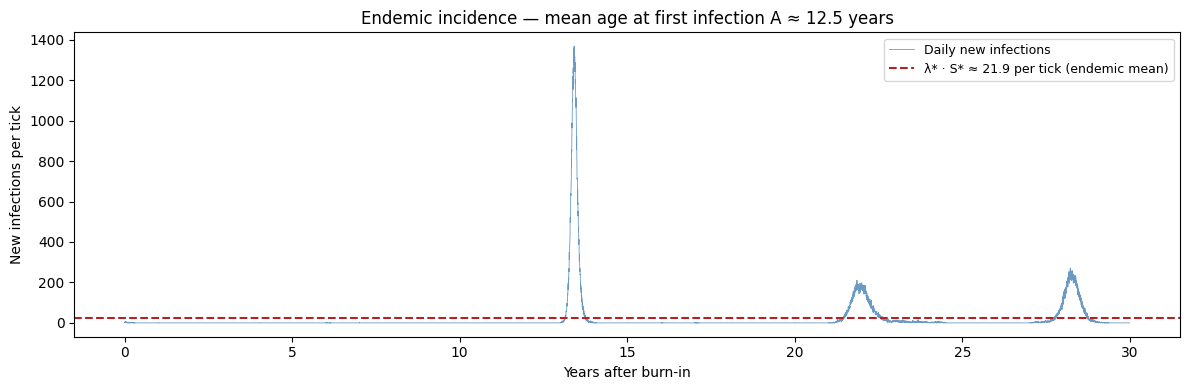


Mean inter-epidemic interval: 7.42 years  (std: 1.04 years)
Number of epidemic peaks detected: 3


In [5]:
# Plot the incidence time series over the endemic period
burn         = 20 * 365
t_endemic    = np.arange(burn, nticks)
t_years      = (t_endemic - burn) / 365.0
incidence_ts = newly_infectious[burn:]

# Expected endemic incidence per tick: lambda* * S* ≈ lambda* * N * (1 - I*/N - R*/N)
# Approximate S* ≈ N/R0 (endemic susceptible fraction)
S_star_frac     = 1.0 / R0
expected_per_tick = lambda_star * S_star_frac * N

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t_years, incidence_ts, linewidth=0.6, color="steelblue",
        alpha=0.8, label="Daily new infections")
ax.axhline(expected_per_tick, color="firebrick", linestyle="--",
           linewidth=1.5, label=f"λ* · S* ≈ {expected_per_tick:.1f} per tick (endemic mean)")

ax.set_xlabel("Years after burn-in")
ax.set_ylabel("New infections per tick")
ax.set_title(f"Endemic incidence — mean age at first infection A ≈ {A_theory_years:.1f} years")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Show inter-epidemic interval as a rough indicator of periodicity
# Find peaks (local maxima) in the smoothed incidence
from scipy.signal import find_peaks
smoothed    = np.convolve(incidence_ts, np.ones(30)/30, mode="same")
peaks, _    = find_peaks(smoothed, distance=180, prominence=10)
if len(peaks) > 1:
    intervals_yr = np.diff(peaks) / 365.0
    print(f"\nMean inter-epidemic interval: {intervals_yr.mean():.2f} years"
          f"  (std: {intervals_yr.std():.2f} years)")
    print(f"Number of epidemic peaks detected: {len(peaks)}")

## Cohort-model limitation

laser.cohorts is a **compartment model**: it tracks the *count* of
individuals in each state (S, I, R), not individual life histories.  This
means we cannot record the exact tick at which a specific person was born
and later infected.

The workaround used here is the **incidence-based approximation**:
* `model.nodes.newly_infectious[t]` records how many people moved from S
  to I on tick t.
* Dividing by S(t) yields the per-capita force of infection λ(t).
* Averaging λ over the endemic period gives λ̄ ≈ λ*.
* The mean age at first infection then follows from the competing-risks
  formula A = 1/λ* (ignoring mortality for simplicity).

For full age-at-infection distributions, an agent-based or age-structured
cohort model is required.